# Lab 4B - COVID19 Regression

In part 2 of this lab we will use multi-layer perceptrons (also called fully connected neural networks) in the context of regression to predict COVID19 cases. 

Created By: Tuan Do & Bernie Boscoe

Latest Update: Tuan Do


## Step 1. Big Picture  
For this task, we will be looking at positive Covid test rates all over the world, from Jan 2020- Aug 2020. Incidentally this is a very popular set used on Kaggle (a machine learning competition site) in inumerable ways. Our goals are as follows:  

Predict COVID19 cases as a function of time and location on Earth. 

We will try to model a slice of our dataset using a fully connected neural network. Our metrics will include: Mean squared error (MSE) to assess training vs test sets, and finding the optimal neural network weights for regression. We will  then trying to assess if we've overfit, or underfit, and possible remedies. (If, during the lab, you are wondering 'why are we doing it this way?' Know that, this is an actual job interview assessment in "the real world". And, of course if you would like to propose a 'better way' to attack the problem (what order, lowest MSE, or, another type of fit, that would be a great discussion topic as well).  


So, keep it simple, there's not too much coding or work that goes into this task. Good luck!

## Step 2. Get the Data

The data you will use here are publicly available world wide COVID cases from Jan. 2020 to Aug. 2020. 

In [2]:
import numpy.matlib as matlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# increase font size
plt.rcParams.update({'font.size': 16})

# load the time_series_covid_19_confirmed.csv using pandas in your lab folder. 

# PUT YOUR ANSWER HERE
data = pd.read_csv('time_series_covid_19_confirmed.csv')

## Step 3. Exploring the Data

## <font color='red'>Question 1
(5 pts)

Check the shape, and head, plot, visualize, and have a look at the data with whatever ways you think will help your task. Comment throughout on observations. Note: There are NaNs (hypothesize why these occur in the dataset). 

</font>

In [95]:
data.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,37856,37894,37953,37999,38054,38070,38113,38129,38140,38143
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,7967,8119,8275,8427,8605,8759,8927,9083,9195,9279
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,40258,40667,41068,41460,41858,42228,42619,43016,43403,43781
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,1024,1045,1045,1045,1060,1060,1098,1098,1124,1124
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,2044,2068,2134,2171,2222,2283,2332,2415,2471,2551


In [25]:
data.describe()

,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,8/20/20,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20
count,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,...,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02
mean,21.076624,22.829441,2.086466,2.458647,3.537594,5.390977,7.962406,11.003759,20.969925,23.180451,...,8.524560e+04,8.626335e+04,8.722006e+04,8.803567e+04,8.888655e+04,8.979638e+04,9.087815e+04,9.192740e+04,9.298665e+04,9.397164e+04
std,24.904600,70.191330,27.279200,27.377862,34.083035,47.434934,66.289178,89.313757,219.187744,220.524977,...,4.488150e+05,4.538117e+05,4.591257e+05,4.630888e+05,4.670401e+05,4.717422e+05,4.774629e+05,4.829942e+05,4.885157e+05,4.940581e+05
min,-51.796300,-135.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.677575,-15.277675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.587500e+02,3.602500e+02,3.690000e+02,3.870000e+02,4.027500e+02,4.087500e+02,4.175000e+02,4.225000e+02,4.357500e+02,4.442500e+02
50%,22.820850,20.921188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.447500e+03,2.467000e+03,2.467000e+03,2.567000e+03,2.544500e+03,2.596500e+03,2.616000e+03,2.704500e+03,2.746000e+03,2.795500e+03
75%,41.143200,77.913685,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.915275e+04,2.972225e+04,2.988800e+04,2.998500e+04,3.006450e+04,3.016525e+04,3.032125e+04,3.043750e+04,3.054975e+04,3.064150e+04
max,71.706900,178.065000,444.000000,444.000000,549.000000,761.000000,1058.000000,1423.000000,3554.000000,3554.000000,...,5.573847e+06,5.622470e+06,5.667070e+06,5.701645e+06,5.739536e+06,5.777710e+06,5.821819e+06,5.867785e+06,5.913941e+06,5.961094e+06


In [73]:
data['Province/State'].dropna().tolist()

['Australian Capital Territory',
 'New South Wales',
 'Northern Territory',
 'Queensland',
 'South Australia',
 'Tasmania',
 'Victoria',
 'Western Australia',
 'Alberta',
 'British Columbia',
 'Diamond Princess',
 'Grand Princess',
 'Manitoba',
 'New Brunswick',
 'Newfoundland and Labrador',
 'Northwest Territories',
 'Nova Scotia',
 'Ontario',
 'Prince Edward Island',
 'Quebec',
 'Saskatchewan',
 'Yukon',
 'Anhui',
 'Beijing',
 'Chongqing',
 'Fujian',
 'Gansu',
 'Guangdong',
 'Guangxi',
 'Guizhou',
 'Hainan',
 'Hebei',
 'Heilongjiang',
 'Henan',
 'Hong Kong',
 'Hubei',
 'Hunan',
 'Inner Mongolia',
 'Jiangsu',
 'Jiangxi',
 'Jilin',
 'Liaoning',
 'Macau',
 'Ningxia',
 'Qinghai',
 'Shaanxi',
 'Shandong',
 'Shanghai',
 'Shanxi',
 'Sichuan',
 'Tianjin',
 'Tibet',
 'Xinjiang',
 'Yunnan',
 'Zhejiang',
 'Faroe Islands',
 'Greenland',
 'French Guiana',
 'French Polynesia',
 'Guadeloupe',
 'Martinique',
 'Mayotte',
 'New Caledonia',
 'Reunion',
 'Saint Barthelemy',
 'Saint Pierre and Miquelon',

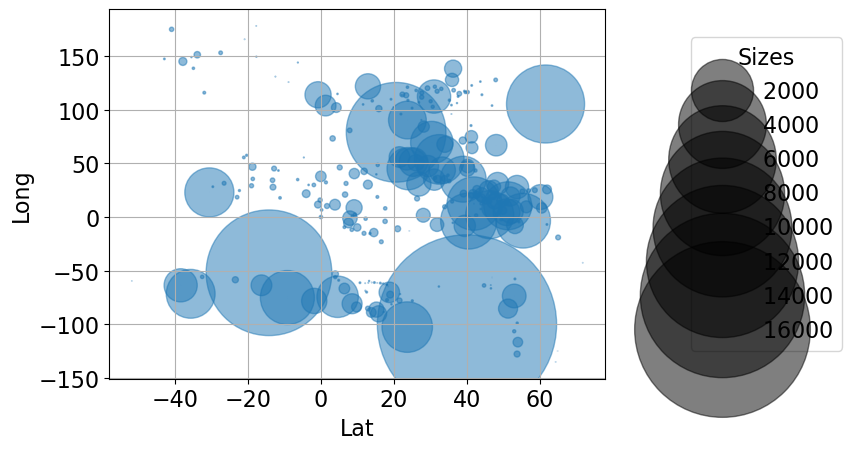

In [104]:
data['tot'] = data.iloc[:,4:].sum(axis=1)

ax = data.plot.scatter(x='Lat', y='Long', s=np.log(data['tot'])*0.000001, c='blue')
# ax = data.plot.scatter(x='Lat', y='Long', s=np.log(data['tot'])*50, c='blue')

# Create scatter plot for the total occurance
scatter = ax.scatter(df['Lat'], df['Long'], s=df['tot']*0.000001, alpha=0.5)
# scatter = ax.scatter(data['Lat'], data['Long'], s=np.log(data['tot'])*50, alpha=0.5)

handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
legend = ax.legend(handles, labels, loc="right",bbox_to_anchor=(1.5, 0.5), title="Sizes")
# legend = ax.legend(handles, labels, loc="right",bbox_to_anchor=(1.5, 0.5), title="Sizes",fontsize=10)

plt.grid(True)
plt.show()

In [88]:
# The most cases
df.loc[df.dropna()['tot'].idxmax()]

Province/State        Hubei
Country/Region        China
Lat                 30.9756
Long               112.2707
1/22/20                 444
                    ...    
8/26/20               68139
8/27/20               68139
8/28/20               68139
8/29/20               68139
tot               576252810
Name: 69, Length: 226, dtype: object

In [89]:
df.loc[(df['Country/Region'] == 'China')]

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,8/21/20,8/22/20,8/23/20,8/24/20,8/25/20,8/26/20,8/27/20,8/28/20,8/29/20,tot
56,Anhui,China,31.8257,117.2264,1,9,15,39,60,70,...,991,991,991,991,991,991,991,991,991,8618400
57,Beijing,China,40.1824,116.4142,14,22,36,41,68,80,...,935,935,935,935,935,935,935,935,935,5852700
58,Chongqing,China,30.0572,107.8740,6,9,27,57,75,110,...,583,583,583,583,583,583,583,583,583,5081790
59,Fujian,China,26.0789,117.9874,1,5,10,18,35,59,...,371,372,375,375,375,375,376,378,380,3026394
60,Gansu,China,35.7518,104.2861,0,2,2,4,7,14,...,169,169,169,169,169,169,169,169,169,1232154
61,Guangdong,China,23.3417,113.4244,26,32,53,78,111,151,...,1725,1727,1727,1730,1734,1734,1735,1737,1738,13624128
62,Guangxi,China,23.8298,108.7881,2,5,23,23,36,46,...,255,255,255,255,255,255,255,255,255,2216886
63,Guizhou,China,26.8154,106.8748,1,3,3,4,5,7,...,147,147,147,147,147,147,147,147,147,1268064
64,Hainan,China,19.1959,109.7453,4,5,8,19,22,33,...,171,171,171,171,171,171,171,171,171,1479534
65,Hebei,China,39.5490,116.1306,1,1,2,8,13,18,...,354,359,359,360,360,362,362,362,362,2876328


## 4. Prepare Data
This step is mostly done for you. But- I highly recommend tracing through this so you understand this common data manipulation. Notice Pandas is being used to examine the data, but we will transform data into different arrays and don't need to think about Pandas when we are analyzing.

In [3]:
# let's only use 50 rows and 100 columns, just to make this easier (and faster)
rows=50
cols=100
data_new=data.iloc[0:rows,4:cols+4]
print(data_new.shape)

(50, 100)


In [4]:
# Now we are going to convert the Tablular data to format {X,Y}, where X={Longitude, Latitude, Date}, Y={#infected}
#Finding the date indices


data_row=data_new.sum(axis=0) # bb per day summing up positive cases into cols
days=range(0,data_row.shape[0])
days_mat=matlib.repmat(np.array(days),data_new.shape[0],1)
print(days_mat.shape)

(50, 100)


In [5]:
#Lets create data X-{X1,X2,X3}, where X1=lat, X2=long, X3=date, Y=#affected
X=np.zeros((days_mat.shape[0]*days_mat.shape[1],3))
Y=np.zeros((days_mat.shape[0]*days_mat.shape[1],1))
lat_long=np.array(data.iloc[:,2:4])
data_new=np.array(data_new)
for r in range(days_mat.shape[0]): #all locations
  X[r*days_mat.shape[1]:r*days_mat.shape[1]+days_mat.shape[1],0]=lat_long[r,0]*np.ones((days_mat.shape[1],)) #setting Latitude
  X[r*days_mat.shape[1]:r*days_mat.shape[1]+days_mat.shape[1],1]=lat_long[r,1]*np.ones((days_mat.shape[1],)) #setting Longitude
  X[r*days_mat.shape[1]:r*days_mat.shape[1]+days_mat.shape[1],2]=np.reshape(days,(days_mat.shape[1],)) #setting the date
  Y[r*days_mat.shape[1]:r*days_mat.shape[1]+days_mat.shape[1]]=np.reshape(data_new[r,:],((days_mat.shape[1],1)))

In [111]:
Y

array([[ 0.],
       [ 0.],
       [ 0.],
       ...,
       [27.],
       [27.],
       [27.]], shape=(5000, 1))

In [6]:
print(np.shape(X))
print(np.shape(Y))
#Data Preparation is Done!

# Check nans
X[np.isnan(X)]

(5000, 3)
(5000, 1)


array([], dtype=float64)

(5000, 3)


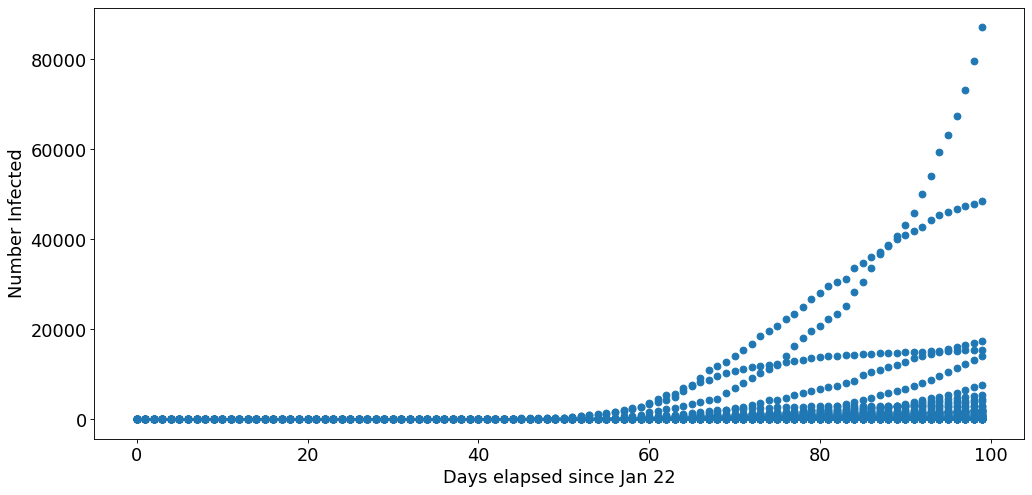

In [7]:
# Let's plot the data in this new format
plt.figure(figsize=(15, 7), dpi=80)
plt.scatter(X[:,2],Y[:])
plt.xlabel('Days elapsed since Jan 22')
plt.ylabel('Number Infected')
print(np.shape(X))

## 5. Select a Model and Train

Here, we will use a multi-layer perceptron (MLP), also called a feed-forward neural network (FNN), or fully-connected neural network for regression. A fully connected neural network is a network where every node in one layer is connected to every node in the next layer. We will just multiple hidden layers to create a network that can learn non-linear relationships between the input and output. 

In [8]:
# First, let's split the training and test data. If you are wondering why we've gone back to just test and train, it is merely to mimic the actual job interview assignment. (In general, train, test, val is better, this is faster)

from sklearn.model_selection import train_test_split
#Split data to train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=10)


### Building a multi-layer perceptron (MLP) for regression with keras and pytorch

In this section, we will learn to use keras (https://keras.io/) and pytorch (https://pytorch.org/), two of the most popular deep learning frameworks, to build and train a neural network for regression. Keras is a high-level wrapper around different types of lower level frameworks such as pytorch, tensorflow, and JAX. The advantage of keras is that it is a common framework so that you can convert to using pytorch or tensorflow easily if you want to. In our textbook (Hands-On Machine Learning), it uses keras with the tensorflow backend, but most of the code will apply for the pytorch backend as well. 



In [9]:
import os
os.environ["KERAS_BACKEND"] = "torch"  # we need to have this line set before importing keras so that keras will use pytorch
import keras
import torch

To create a neural network, we first define the sequence of layers. Below is an example neural network with 3 neurons in the input layer, two hidden layers, with 5 neurons in each hidden layer, and one neuron in the output layer. We will use ReLU as our activation function. Read more about the `Dense()` function to create fully connected layers here: https://keras.io/api/layers/core_layers/dense/

In [10]:
model = keras.Sequential([
    keras.Input((3,)), # input layer
    keras.layers.Dense(5, activation="relu"), # first hidden layer
    keras.layers.Dense(5, activation="relu"), # second hidden layer
    keras.layers.Dense(1)
])

We now need to compile the model in order to train it. The compile function takes in the optimizer, loss function, and metrics to evaluate during training. Read more about the compile function here: https://keras.io/api/models/model_training_apis/#compile-method 

Here, we will use the Adam optimizer and mean squared error loss function.

In [11]:
# compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.02),
    loss="mse"
)

Now we can train the model. The fit function takes in the training data and the number of epochs to train for. Read more about the fit function here: https://keras.io/api/models/model_training_apis/#fit-method


In [12]:
## NOTE: if you run this cell multple times, it will continue to train from the last time this cell is run. This means that if you train for 100 epochs, then rerun this cell, it will train for another 100 for a total of 200. If you want to retrain your model from scratch, you need to create the model the compile it again before training!

# this might make take a while to train depending on the number of epochs
history = model.fit(X_train, y_train, epochs=100, 
    validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
    batch_size = 128,
    verbose=0 # set to 1 to display the loss and validation loss at every epoch
)

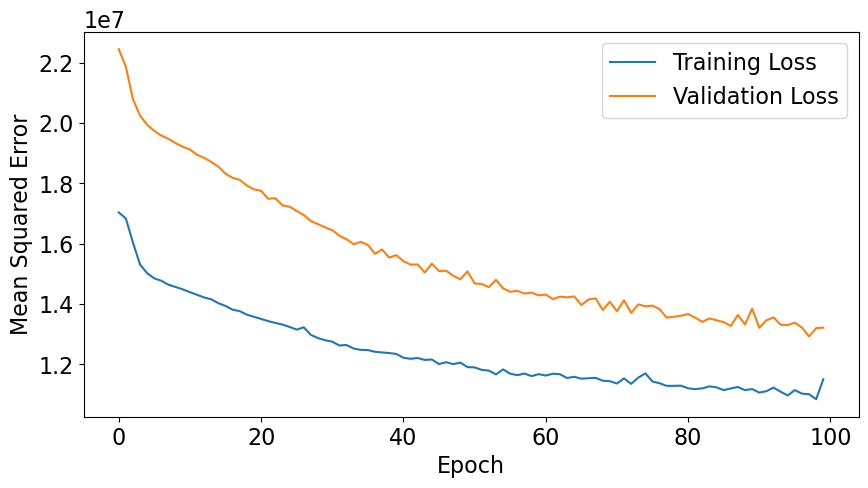

In [20]:
# examine how the loss changes as a function of epochs for the training and the internal validation splits
plt.figure(figsize=(10, 5))
# Plot training loss
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4')
# Plot validation loss
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e')
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch')
plt.legend()

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Text(0, 0.5, 'Number Infected')

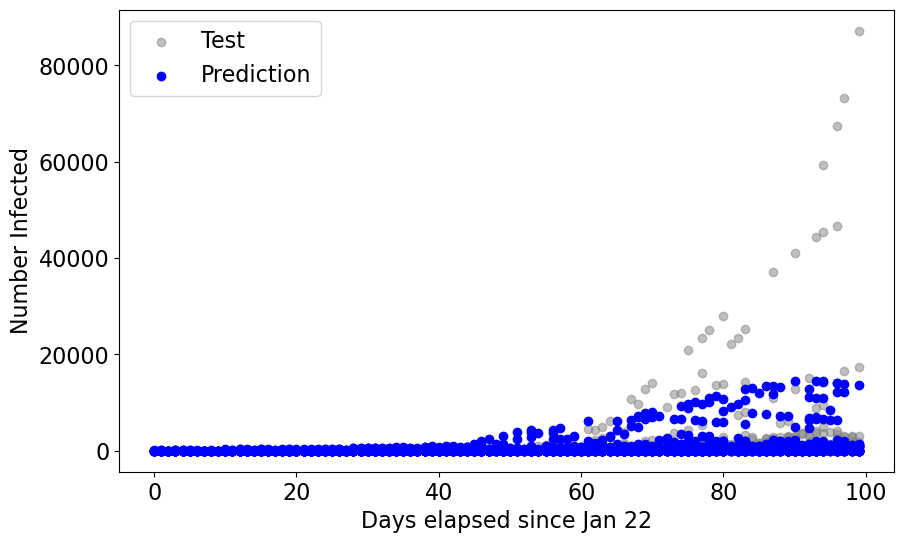

In [123]:
# make model predictions using the test data
predictions = model.predict(X_test)

# plot the model predictions
plt.figure(figsize=(10,6))
plt.scatter(X_test[:,2], y_test, label='Test', color='gray', alpha=0.5)
plt.scatter(X_test[:,2], predictions, label='Prediction', color='blue')
plt.legend()
plt.xlabel('Days elapsed since Jan 22')
plt.ylabel('Number Infected')

## Saving the model
We can use keras to save the model so that we don't need to train it to make predictions for next it. It is also important to save your models as a record of the experiment. 

In [124]:
# Save the entire model to a single file
model_save_file = 'covid19_initial_model.keras'
model.save(model_save_file)
print("Model saved to disk:" + model_save_file)

Model saved to disk:covid19_initial_model.keras


## Loading the model

Once you have a .keras data file, you can load it into your program using the following code:

In [62]:
# This code is purposely commented out. Uncomment it if you want to load a model

# Load the model exactly as it was
#reloaded_model = keras.models.load_model("covid19_initial_model.keras")

# Verify it works by making a prediction
#prediction = reloaded_model.predict(X_test)


## <font color='red'>Question 2 (8 pts)

Run the cells above to create and train the initial model. Answer the following questions:

1. How many parameters are there in the model? How did you determine this? (1 pt)
2. Explain what is a batch size in training? (1 pt)
3. Explain what is the learning rate? (1 pt)
4. What is the difference between training loss and validation loss? (1 pt)
5. Describe the learning curve of the model. What do you notice about the training and validation curves? (2 pt)
6. Describe the final performance of the model. What fits well and what fits poorly? (2 pt)

</font>

# Answers

> model.fit(X_train, y_train, epochs=100, 
    validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
    batch_size = 128,
    verbose=0
    
1. How many parameters are there in the model? How did you determine this? (1 pt)
> The number of weights in one batch is 128x5 + 5x5 + 5x1 = 670, # of biases in a batch = 11.  There are [50000/128] = 391 batches, where the last one batch has only 80 samples. In the last batch, there are 80x5 + 5x5 + 5x1 = 430 weights and 11 biases.  Hence, the total number of weights and biases are (670+11)*390 + (430 + 11) = 266031.

2. Explain what is a batch size in training? (1 pt)
> The number of samples within a batch.  We have 128 samples within a batch and 391 batches.
 
3.  Explain what is the learning rate? (1 pt)
> The step size in each backward descent in the gradient direction (steepest direction).

4.  What is the difference between training loss and validation loss? (1 pt)
> training loss is the mean square error of the training samples and the validation loss is within the validation samples.  Here, these are 1.2x10^7, 1.3x10^7 respectively.

5.  Describe the learning curve of the model. What do you notice about the training and validation curves? (2 pt)
> The errors are decreasing with deceleration and sometimes oscillate.  This might indicate the training is not complete.

6.  Describe the final performance of the model. What fits well and what fits poorly? (2 pt)
> Looking at the predicted numbers of covid outbreaks per day for the test set, it didn't really do well compared to the test data for the ones that trend exponentially.  

In [19]:
print(f'loss: {history.history['loss'][-1]}, val loss: {history.history['val_loss'][-1]}')

loss: 11503054.0, val loss: 13211370.0


## Step 6 - Fine Tune the Model

Neural networks can have many hyperparameters. Hyperparameters are parameters that are not learned from the data, but are set before training the model. These include the number of hidden layers, the number of nodes in each hidden layer, the activation function, the optimizer, the learning rate, and the number of epochs. 

## <font color='red'>Question 3 (12 pts)

1. Create a new model with the same architecture as the initial model, but with a different number of epochs (e.g., 200 epochs instead of 100 epochs). Train the model and examine how the loss changes as a function of epochs for the training and the internal validation splits. Describe how the model performance changes as a function of epochs. Also describe the overall model performance after training. (3 pts)

2. Now, create a new model with the same architecture as the initial model, but with a different learning rate. Train the model and examine how the loss changes as a function of epochs for the training and the internal validation splits. Describe how sensitive the model is to learning rate. What happens if learning rate is too small or too large (vary by factors of 10 for this test). (3 pts)

3. Explore how the model performance changes as a function of the number of hidden layers and the number of hidden units per layer. (3 pts)

4. What did you find to be the best model architecture for this problem? Why? (3 pts)


</font>

# Answer to Q3-1: (epoch)
>Create a new model with the same architecture as the initial model, but with a different number of epochs (e.g., 200 epochs instead of 100 epochs). Train the model and examine how the loss changes as a function of epochs for the training and the internal validation splits. Describe how the model performance changes as a function of epochs. Also describe the overall model performance after training. (3 pts)


The plot below is the loss after the 500 epochs.  Increasing epochs didn't decrease the loss dramatically and there are some oscillations (indicating the learning rate needs to be smaller at the very end?).

The plot after is the loss of training and validation data at final epoch as a function of epochs from 100 to 900.  The loss decreases by about 3-fold, which means there are still room for more training.

The last plot shows the prediction from the final model.  The performance of prediction improved, now predicting the exponentially grown occurances as well (some of them).

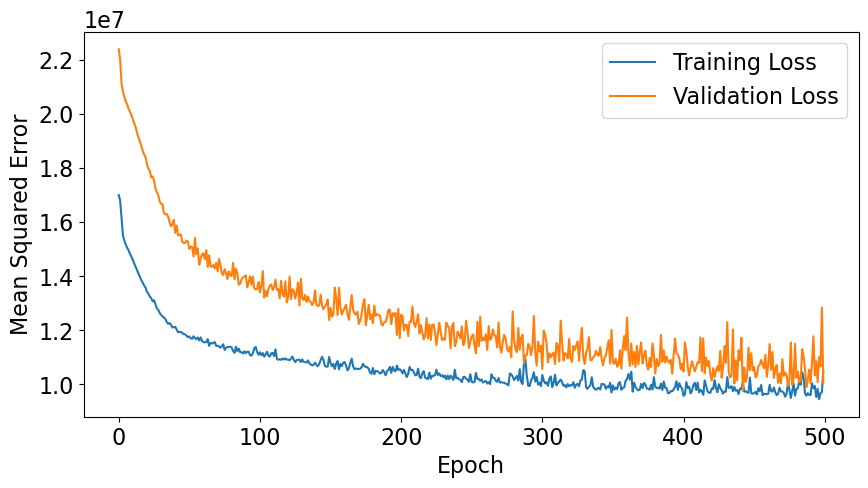

In [26]:
model = keras.Sequential([
    keras.Input((3,)), # input layer
    keras.layers.Dense(5, activation="relu"), # first hidden layer
    keras.layers.Dense(5, activation="relu"), # second hidden layer
    keras.layers.Dense(1)
])
# compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.02),
    loss="mse"
)

history2 = model.fit(X_train, y_train, epochs=500, 
    validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
    batch_size = 128,
    verbose=0 # set to 1 to display the loss and validation loss at every epoch
)
plt.figure(figsize=(10, 5))
# Plot training loss
plt.plot(history2.history['loss'], label='Training Loss', color='#1f77b4')
# Plot validation loss
plt.plot(history2.history['val_loss'], label='Validation Loss', color='#ff7f0e')
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch')
plt.legend()

In [37]:
# Answer to 1: changing epochs
losses = []
val_losses = []
x = np.arange(1,11,1)
for i in x:
    model = keras.Sequential([
    keras.Input((3,)), # input layer
    keras.layers.Dense(5, activation="relu"), # first hidden layer
    keras.layers.Dense(5, activation="relu"), # second hidden layer
    keras.layers.Dense(1)
    ])
    # compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.02),
        loss="mse"
    )
    
    history2 = model.fit(X_train, y_train, epochs=i*100, 
        validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
        batch_size = 128,
        verbose=0 # set to 1 to display the loss and validation loss at every epoch
    )
    losses.append(history2.history['loss'][-1])
    val_losses.append(history2.history['val_loss'][-1])


The code block above is too slow; I'll do something quick below.

In [45]:
# not initialise the neural network for the speedy training
losses = []
val_losses = []
x = np.arange(1,15,1)
model = keras.Sequential([
    keras.Input((3,)), # input layer
    keras.layers.Dense(5, activation="relu"), # first hidden layer
    keras.layers.Dense(5, activation="relu"), # second hidden layer
    keras.layers.Dense(1)
    ])
# compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.02),
    loss="mse"
)
    
for i in x:
    history2 = model.fit(X_train, y_train, epochs=100, 
        validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
        batch_size = 128,
        verbose=0 # set to 1 to display the loss and validation loss at every epoch
    )
    losses.append(history2.history['loss'][-1])
    val_losses.append(history2.history['val_loss'][-1])


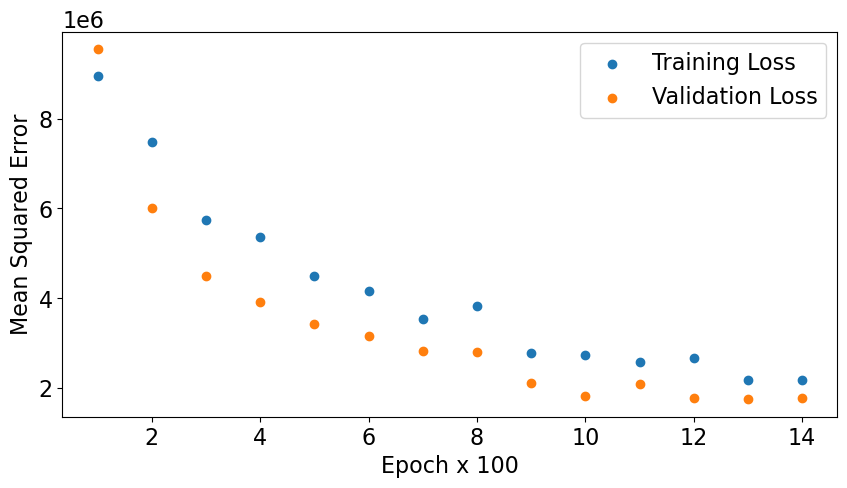

In [46]:
plt.figure(figsize=(10, 5))
# Plot training loss
plt.scatter(x,losses, label='Training Loss', color='#1f77b4')
# Plot validation loss
plt.scatter(x,val_losses, label='Validation Loss', color='#ff7f0e')
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch x 100')
plt.legend()

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Text(0, 0.5, 'Number Infected')

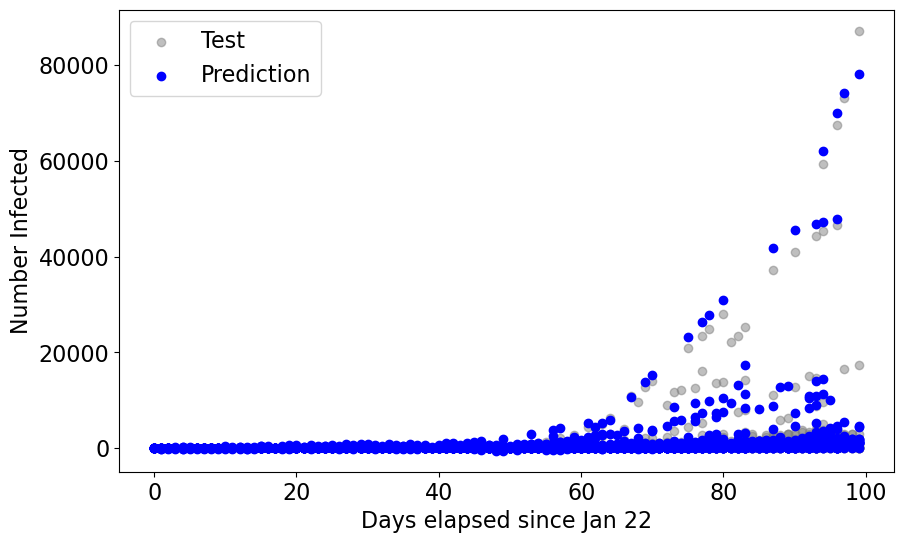

In [47]:
predictions = model.predict(X_test)

# plot the model predictions
plt.figure(figsize=(10,6))
plt.scatter(X_test[:,2], y_test, label='Test', color='gray', alpha=0.5)
plt.scatter(X_test[:,2], predictions, label='Prediction', color='blue')
plt.legend()
plt.xlabel('Days elapsed since Jan 22')
plt.ylabel('Number Infected')

# Q3-2
> Now, create a new model with the same architecture as the initial model, but with a different learning rate. Train the model and examine how the loss changes as a function of epochs for the training and the internal validation splits. Describe how sensitive the model is to learning rate. What happens if learning rate is too small or too large (vary by factors of 10 for this test). (3 pts)

Scanning the learning rate from 0.001 to 0.04, I found that leraning rate = 0.02 has the least total loss.


In [48]:
# experimenting with the initial learning rate.
losses = []
val_losses = []
x = np.arange(1,16,1)

    
for i in x:
    model = keras.Sequential([
    keras.Input((3,)), # input layer
    keras.layers.Dense(5, activation="relu"), # first hidden layer
    keras.layers.Dense(5, activation="relu"), # second hidden layer
    keras.layers.Dense(1)
    ])
    # compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001*i),
        loss="mse"
    )
    history2 = model.fit(X_train, y_train, epochs=100, 
        validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
        batch_size = 128,
        verbose=0 # set to 1 to display the loss and validation loss at every epoch
    )
    losses.append(history2.history['loss'][-1])
    val_losses.append(history2.history['val_loss'][-1])


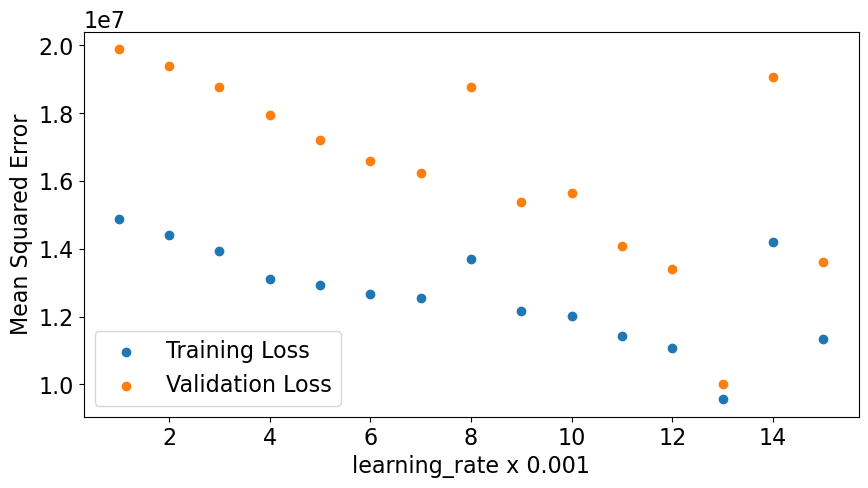

In [49]:
plt.figure(figsize=(10, 5))
# Plot training loss
plt.scatter(x,losses, label='Training Loss', color='#1f77b4')
# Plot validation loss
plt.scatter(x,val_losses, label='Validation Loss', color='#ff7f0e')
plt.ylabel('Mean Squared Error')
plt.xlabel('learning_rate x 0.001')
plt.legend()

In [51]:
# experimenting with the initial learning rate.
losses = []
val_losses = []
x = np.arange(10,41,2)

    
for i in x:
    model = keras.Sequential([
    keras.Input((3,)), # input layer
    keras.layers.Dense(5, activation="relu"), # first hidden layer
    keras.layers.Dense(5, activation="relu"), # second hidden layer
    keras.layers.Dense(1)
    ])
    # compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001*i),
        loss="mse"
    )
    history2 = model.fit(X_train, y_train, epochs=100, 
        validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
        batch_size = 128,
        verbose=0 # set to 1 to display the loss and validation loss at every epoch
    )
    losses.append(history2.history['loss'][-1])
    val_losses.append(history2.history['val_loss'][-1])


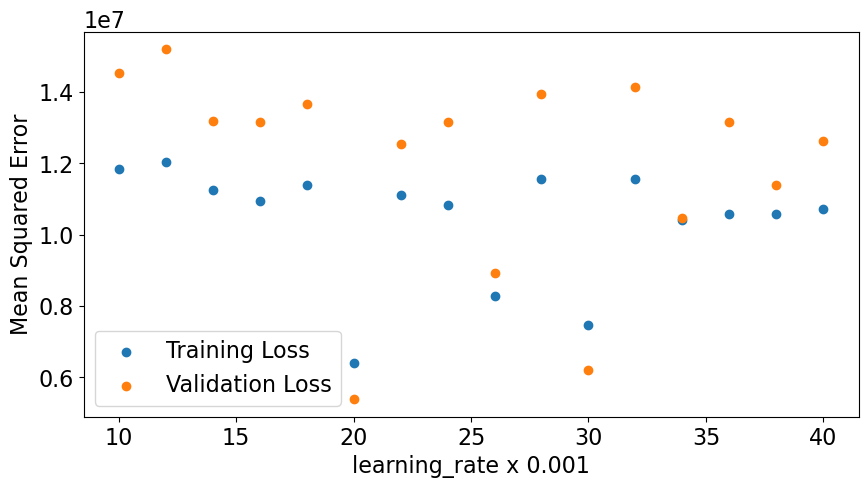

In [52]:
plt.figure(figsize=(10, 5))
# Plot training loss
plt.scatter(x,losses, label='Training Loss', color='#1f77b4')
# Plot validation loss
plt.scatter(x,val_losses, label='Validation Loss', color='#ff7f0e')
plt.ylabel('Mean Squared Error')
plt.xlabel('learning_rate x 0.001')
plt.legend()

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Text(0, 0.5, 'Number Infected')

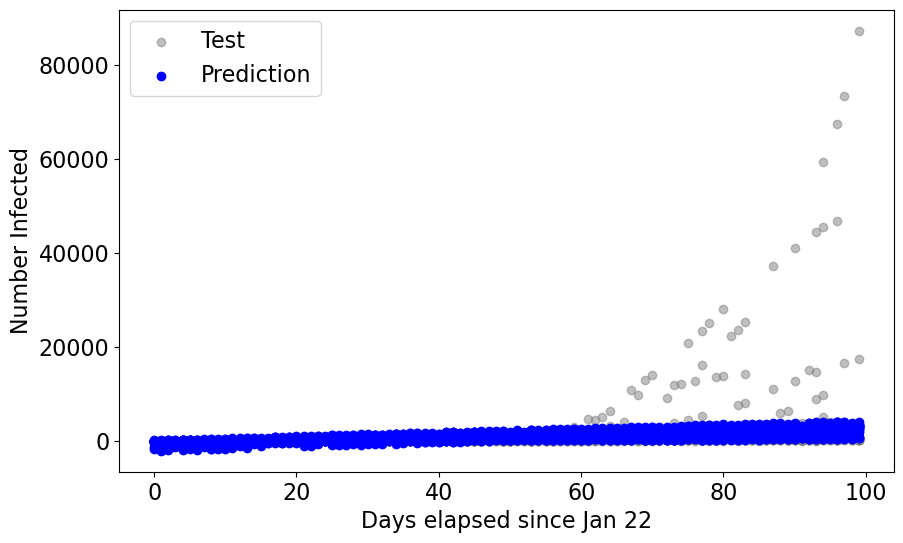

In [65]:
model = keras.Sequential([
    keras.Input((3,)), # input layer
    keras.layers.Dense(5, activation="relu"), # first hidden layer
    keras.layers.Dense(5, activation="relu"), # second hidden layer
    keras.layers.Dense(1)
    ])
# compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.002),
    loss="mse"
)
history2 = model.fit(X_train, y_train, epochs=100, 
    validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
    batch_size = 128,
    verbose=0 # set to 1 to display the loss and validation loss at every epoch
)

predictions = model.predict(X_test)

# plot the model predictions
plt.figure(figsize=(10,6))
plt.scatter(X_test[:,2], y_test, label='Test', color='gray', alpha=0.5)
plt.scatter(X_test[:,2], predictions, label='Prediction', color='blue')
plt.legend()
plt.xlabel('Days elapsed since Jan 22')
plt.ylabel('Number Infected')

# Q3-3: 
> Explore how the model performance changes as a function of the number of hidden layers and the number of hidden units per layer. (3 pts)

From 5 to 25 layers, the total loss decreases monotonically with the number of layers.  But from 25 to 100 layers, it fluctuates a lot, with 40 and 100 layers seeming to have the minimal loss.

With 100 neurons at each layer (100 epochs, 2 hidden layers, learning rate 0.2), it predicts the exponential growth in the number of outbreaks that were previously missed.  

In [55]:
losses = []
val_losses = []
x = np.arange(5,26,2)

    
for i in x:
    model = keras.Sequential([
    keras.Input((3,)), # input layer
    keras.layers.Dense(int(i), activation="relu"), # first hidden layer
    keras.layers.Dense(int(i), activation="relu"), # second hidden layer
    keras.layers.Dense(1)
    ])
    # compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.02),
        loss="mse"
    )
    history2 = model.fit(X_train, y_train, epochs=100, 
        validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
        batch_size = 128,
        verbose=0 # set to 1 to display the loss and validation loss at every epoch
    )
    losses.append(history2.history['loss'][-1])
    val_losses.append(history2.history['val_loss'][-1])


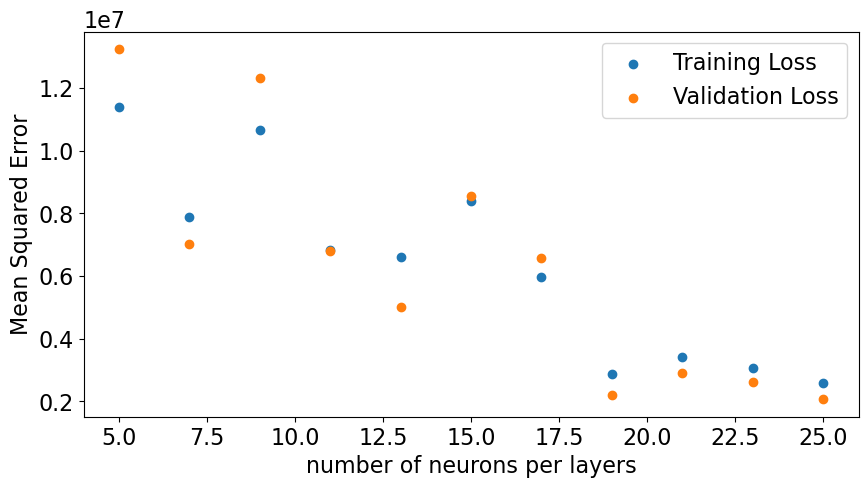

In [56]:
plt.figure(figsize=(10, 5))
# Plot training loss
plt.scatter(x,losses, label='Training Loss', color='#1f77b4')
# Plot validation loss
plt.scatter(x,val_losses, label='Validation Loss', color='#ff7f0e')
plt.ylabel('Mean Squared Error')
plt.xlabel('number of neurons per layers')
plt.legend()

In [57]:
losses = []
val_losses = []
x = np.arange(25,101,5)

    
for i in x:
    model = keras.Sequential([
    keras.Input((3,)), # input layer
    keras.layers.Dense(int(i), activation="relu"), # first hidden layer
    keras.layers.Dense(int(i), activation="relu"), # second hidden layer
    keras.layers.Dense(1)
    ])
    # compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.02),
        loss="mse"
    )
    history2 = model.fit(X_train, y_train, epochs=100, 
        validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
        batch_size = 128,
        verbose=0 # set to 1 to display the loss and validation loss at every epoch
    )
    losses.append(history2.history['loss'][-1])
    val_losses.append(history2.history['val_loss'][-1])


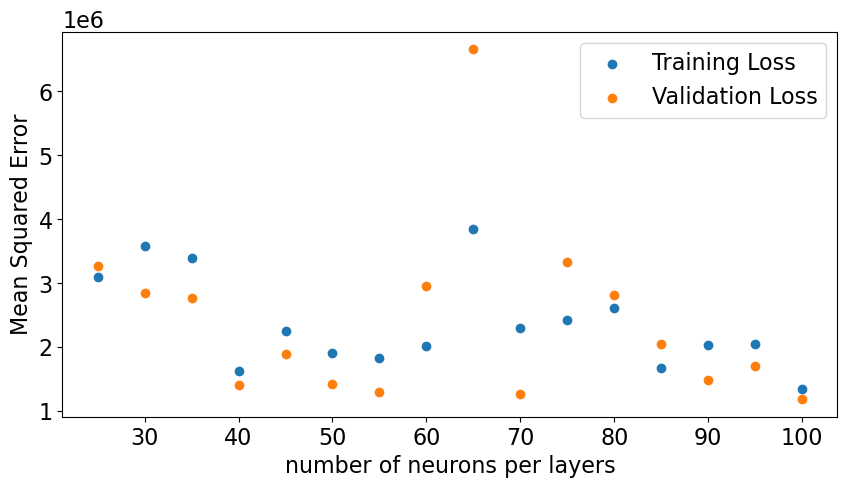

In [58]:
plt.figure(figsize=(10, 5))
# Plot training loss
plt.scatter(x,losses, label='Training Loss', color='#1f77b4')
# Plot validation loss
plt.scatter(x,val_losses, label='Validation Loss', color='#ff7f0e')
plt.ylabel('Mean Squared Error')
plt.xlabel('number of neurons per layers')
plt.legend()

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Text(0, 0.5, 'Number Infected')

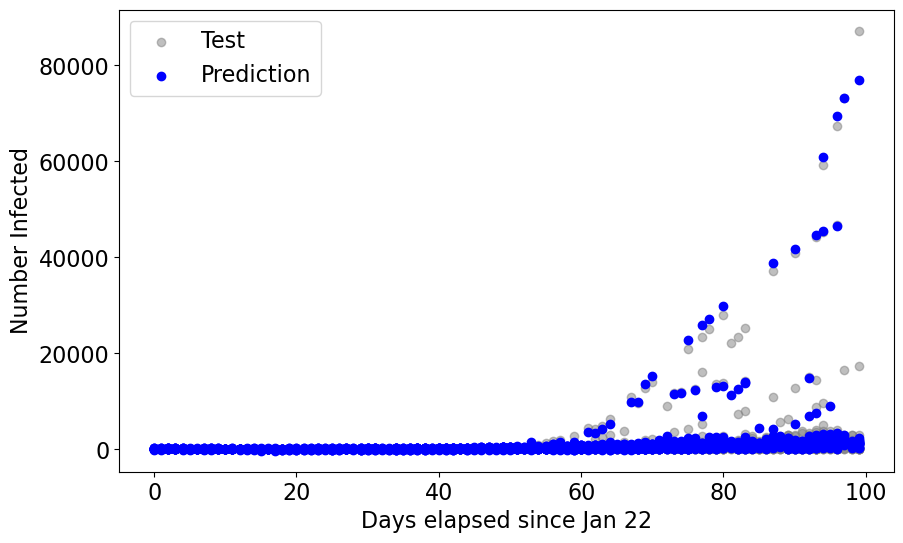

In [60]:
model = keras.Sequential([
    keras.Input((3,)), # input layer
    keras.layers.Dense(100, activation="relu"), # first hidden layer
    keras.layers.Dense(100, activation="relu"), # second hidden layer
    keras.layers.Dense(1)
    ])
# compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.02),
    loss="mse"
)
history2 = model.fit(X_train, y_train, epochs=100, 
    validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
    batch_size = 128,
    verbose=0 # set to 1 to display the loss and validation loss at every epoch
)
losses.append(history2.history['loss'][-1])
val_losses.append(history2.history['val_loss'][-1])

predictions = model.predict(X_test)

# plot the model predictions
plt.figure(figsize=(10,6))
plt.scatter(X_test[:,2], y_test, label='Test', color='gray', alpha=0.5)
plt.scatter(X_test[:,2], predictions, label='Prediction', color='blue')
plt.legend()
plt.xlabel('Days elapsed since Jan 22')
plt.ylabel('Number Infected')

# Increasing the number of layers

In [61]:
losses = []
val_losses = []
x = np.arange(5,26,2)

# two layers    
model = keras.Sequential([
keras.Input((3,)), # input layer
keras.layers.Dense(5, activation="relu"), # first hidden layer
keras.layers.Dense(5, activation="relu"), # second hidden layer
keras.layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.02),
    loss="mse"
)
history2 = model.fit(X_train, y_train, epochs=100, 
    validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
    batch_size = 128,
    verbose=0 # set to 1 to display the loss and validation loss at every epoch
)
losses.append(history2.history['loss'][-1])
val_losses.append(history2.history['val_loss'][-1])

# four layers
model = keras.Sequential([
keras.Input((3,)), # input layer
keras.layers.Dense(5, activation="relu"), # first hidden layer
keras.layers.Dense(5, activation="relu"), # second hidden layer
keras.layers.Dense(5, activation="relu"), # third hidden layer
keras.layers.Dense(5, activation="relu"),
keras.layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.02),
    loss="mse"
)
history2 = model.fit(X_train, y_train, epochs=100, 
    validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
    batch_size = 128,
    verbose=0 # set to 1 to display the loss and validation loss at every epoch
)
losses.append(history2.history['loss'][-1])
val_losses.append(history2.history['val_loss'][-1])

# six layers
model = keras.Sequential([
keras.Input((3,)), # input layer
keras.layers.Dense(5, activation="relu"), # first hidden layer
keras.layers.Dense(5, activation="relu"), # second hidden layer
keras.layers.Dense(5, activation="relu"), # third hidden layer
keras.layers.Dense(5, activation="relu"),
keras.layers.Dense(5, activation="relu"),
keras.layers.Dense(5, activation="relu"),
keras.layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.02),
    loss="mse"
)
history2 = model.fit(X_train, y_train, epochs=100, 
    validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
    batch_size = 128,
    verbose=0 # set to 1 to display the loss and validation loss at every epoch
)
losses.append(history2.history['loss'][-1])
val_losses.append(history2.history['val_loss'][-1])

# eight layers
model = keras.Sequential([
keras.Input((3,)), # input layer
keras.layers.Dense(5, activation="relu"), # first hidden layer
keras.layers.Dense(5, activation="relu"), # second hidden layer
keras.layers.Dense(5, activation="relu"), # third hidden layer
keras.layers.Dense(5, activation="relu"),
keras.layers.Dense(5, activation="relu"),
keras.layers.Dense(5, activation="relu"),
keras.layers.Dense(5, activation="relu"),
keras.layers.Dense(5, activation="relu"),
keras.layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.02),
    loss="mse"
)
history2 = model.fit(X_train, y_train, epochs=100, 
    validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
    batch_size = 128,
    verbose=0 # set to 1 to display the loss and validation loss at every epoch
)
losses.append(history2.history['loss'][-1])
val_losses.append(history2.history['val_loss'][-1])



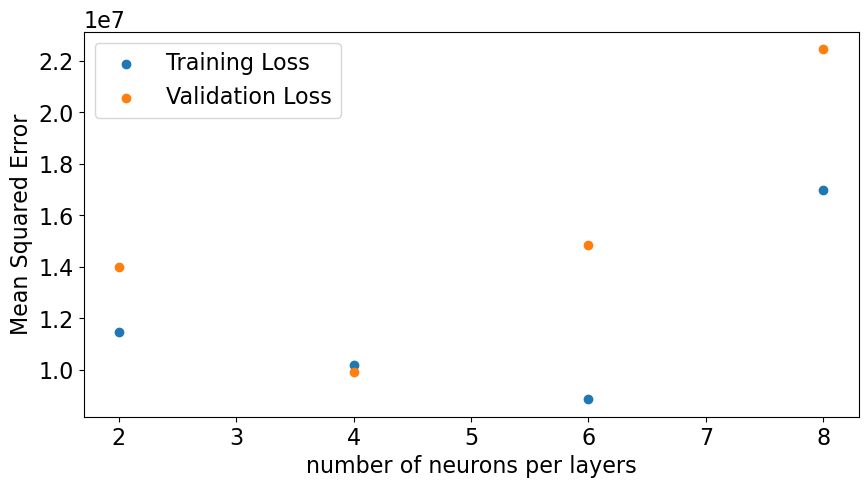

In [63]:
x = np.arange(2,9,2)
plt.figure(figsize=(10, 5))
# Plot training loss
plt.scatter(x,losses, label='Training Loss', color='#1f77b4')
# Plot validation loss
plt.scatter(x,val_losses, label='Validation Loss', color='#ff7f0e')
plt.ylabel('Mean Squared Error')
plt.xlabel('number of neurons per layers')
plt.legend()

Text(0, 0.5, 'Number Infected')

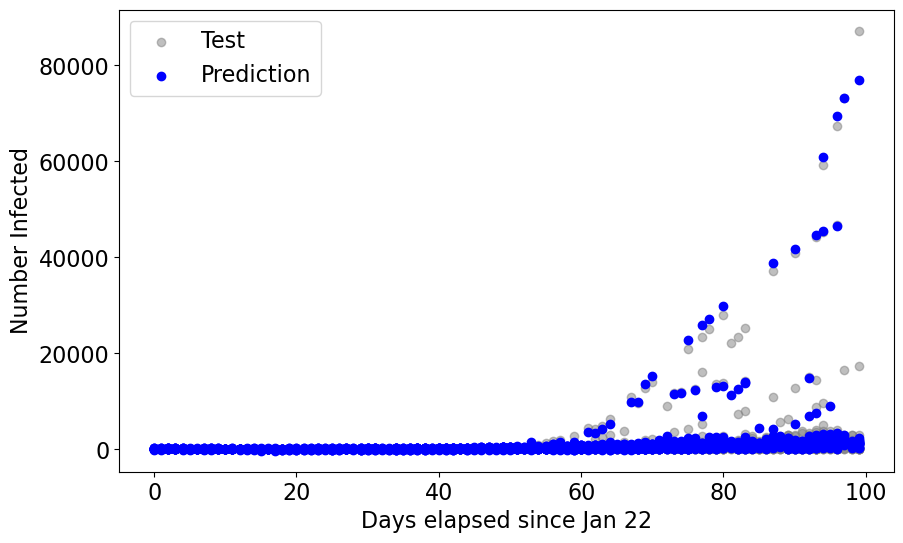

In [64]:
# four layers
model = keras.Sequential([
keras.Input((3,)), # input layer
keras.layers.Dense(5, activation="relu"), # first hidden layer
keras.layers.Dense(5, activation="relu"), # second hidden layer
keras.layers.Dense(5, activation="relu"), # third hidden layer
keras.layers.Dense(5, activation="relu"),
keras.layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.02),
    loss="mse"
)
history2 = model.fit(X_train, y_train, epochs=100, 
    validation_split=0.2, # the model will internally take out random set of 0.2 of the data to compute the validation loss at each step
    batch_size = 128,
    verbose=0 # set to 1 to display the loss and validation loss at every epoch
)
losses.append(history2.history['loss'][-1])
val_losses.append(history2.history['val_loss'][-1])


# plot the model predictions
plt.figure(figsize=(10,6))
plt.scatter(X_test[:,2], y_test, label='Test', color='gray', alpha=0.5)
plt.scatter(X_test[:,2], predictions, label='Prediction', color='blue')
plt.legend()
plt.xlabel('Days elapsed since Jan 22')
plt.ylabel('Number Infected')

## Step 7 - Present your solution

## <font color='red'>Question 4 (6 pts)

1. Describe examples where the model worked well and examples where it failed. Hypothesize why this happened. (3 pts)

2. What are the implications of this model for our original goal of COVID19 prediction? (3 pts)

</font>

# Q4 answers:
> 1. Describe examples where the model worked well and examples where it failed. Hypothesize why this happened. (3 pts)

Within my scanning range for the learning rate, 0.001 to 0.04, 0.02 was the optimal while it didn't predict the exponential growth of outbreaks.

But changing the number of neurons to 100 (with all other parameters unchanged), number of layers to 4, epochs to 1500 could predict the exponential growth of outbreaks while not well about some other intermediate numbers.  Their performances seem to be equally good.

> 2. What are the implications of this model for our original goal of COVID19 prediction? (3 pts)
>
The neural network seems to predict well for the test data for the exponentially growing outbreaks and lowlying ones but not the intermediate ones.
